In [7]:
# Load and Setup Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA_DIR = "."
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_val   = pd.read_csv(f"{DATA_DIR}/X_val.csv")
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze("columns")
y_val   = pd.read_csv(f"{DATA_DIR}/y_val.csv").squeeze("columns")
y_test  = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze("columns")

# Drop non-numeric columns
X_train = X_train.drop(columns=['Country Name', 'Year'])
X_val   = X_val.drop(columns=['Country Name', 'Year'])
X_test  = X_test.drop(columns=['Country Name', 'Year'])

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

def evaluate(model, X, y, label):
    pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    print(f"  {label:5s}  RMSE={rmse:10.3f}   MAE={mae:10.3f}   R²={r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

Train: (1498, 12)  Val: (469, 12)  Test: (503, 12)


In [8]:
# Decision Tree Regression

dt_results = []
for depth in [3, 5, 7, 10, 15, 20, None]:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    val_pred = dt.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    val_r2   = r2_score(y_val, val_pred)
    dt_results.append({"max_depth": depth, "val_rmse": val_rmse, "val_r2": val_r2})
    print(f"  max_depth={str(depth):>4s}   val RMSE={val_rmse:10.3f}   val R²={val_r2:.4f}")
 
dt_df = pd.DataFrame(dt_results)
best_dt_depth_raw = dt_df.loc[dt_df["val_rmse"].idxmin(), "max_depth"]
best_dt_depth = None if pd.isna(best_dt_depth_raw) else int(best_dt_depth_raw)
print(f"\n  → Best max_depth (lowest val RMSE): {best_dt_depth}")

best_dt = DecisionTreeRegressor(max_depth=best_dt_depth, random_state=42)
best_dt.fit(X_train, y_train)
print("Final Decision Tree performance:")
evaluate(best_dt, X_train, y_train, "Train")
evaluate(best_dt, X_val,   y_val,   "Val")
dt_test_metrics = evaluate(best_dt, X_test, y_test, "Test")

  max_depth=   3   val RMSE=  1057.635   val R²=0.0810
  max_depth=   5   val RMSE=   886.197   val R²=0.3548
  max_depth=   7   val RMSE=   871.361   val R²=0.3762
  max_depth=  10   val RMSE=   872.602   val R²=0.3744
  max_depth=  15   val RMSE=   871.530   val R²=0.3760
  max_depth=  20   val RMSE=   888.328   val R²=0.3517
  max_depth=None   val RMSE=   883.885   val R²=0.3582

  → Best max_depth (lowest val RMSE): 7
Final Decision Tree performance:
  Train  RMSE=    38.256   MAE=    21.039   R²=0.9990
  Val    RMSE=   871.361   MAE=   223.169   R²=0.3762
  Test   RMSE=   316.008   MAE=   129.782   R²=0.3180


In [12]:
# Random Forest Regression

configs = [
    (300, 6, 5),
    (300, 6, 10),
    (300, 6, 20),
    (300, 8, 5),
    (300, 8, 10),
    (300, 8, 20),
    (300, 10, 10),
    (300, 10, 20),
    (300, 10, 50),
]

rf_results = []
for n_est, depth, min_leaf in configs:
    rf = RandomForestRegressor(
        n_estimators=n_est,
        max_depth=depth,
        min_samples_leaf=min_leaf,
        n_jobs=-1,
        random_state=42,
    )
    rf.fit(X_train, y_train)
    val_pred  = rf.predict(X_val)
    train_pred = rf.predict(X_train)
    val_rmse  = np.sqrt(mean_squared_error(y_val, val_pred))
    val_r2    = r2_score(y_val, val_pred)
    train_r2  = r2_score(y_train, train_pred)
    rf_results.append({
        "n_estimators": n_est, "max_depth": depth,
        "min_samples_leaf": min_leaf,
        "val_rmse": val_rmse, "val_r2": val_r2, "train_r2": train_r2,
    })
    print(f"  depth={depth:3d}  min_leaf={min_leaf:3d}  "
          f"train_r2={train_r2:.4f}  val_r2={val_r2:.4f}  val_rmse={val_rmse:.3f}")

rf_df = pd.DataFrame(rf_results)
best_rf_row = rf_df.loc[rf_df["val_rmse"].idxmin()]
print(f"\n  → Best RF config: {best_rf_row.to_dict()}")

best_rf = RandomForestRegressor(
    n_estimators=int(best_rf_row["n_estimators"]),
    max_depth=int(best_rf_row["max_depth"]),
    min_samples_leaf=int(best_rf_row["min_samples_leaf"]),
    n_jobs=-1,
    random_state=42,
)
best_rf.fit(X_train, y_train)
print("\nFinal Random Forest performance:")
evaluate(best_rf, X_train, y_train, "Train")
evaluate(best_rf, X_val,   y_val,   "Val")
rf_test_metrics = evaluate(best_rf, X_test, y_test, "Test")

  depth=  6  min_leaf=  5  train_r2=0.9934  val_r2=0.3586  val_rmse=883.602
  depth=  6  min_leaf= 10  train_r2=0.9597  val_r2=0.3487  val_rmse=890.372
  depth=  6  min_leaf= 20  train_r2=0.8255  val_r2=0.2914  val_rmse=928.703
  depth=  8  min_leaf=  5  train_r2=0.9940  val_r2=0.3608  val_rmse=882.066
  depth=  8  min_leaf= 10  train_r2=0.9603  val_r2=0.3499  val_rmse=889.582
  depth=  8  min_leaf= 20  train_r2=0.8256  val_r2=0.2914  val_rmse=928.691
  depth= 10  min_leaf= 10  train_r2=0.9604  val_r2=0.3498  val_rmse=889.588
  depth= 10  min_leaf= 20  train_r2=0.8256  val_r2=0.2915  val_rmse=928.667
  depth= 10  min_leaf= 50  train_r2=0.4373  val_r2=0.4795  val_rmse=795.940

  → Best RF config: {'n_estimators': 300.0, 'max_depth': 10.0, 'min_samples_leaf': 50.0, 'val_rmse': 795.9398411339241, 'val_r2': 0.479527707820103, 'train_r2': 0.43732711768731036}

Final Random Forest performance:
  Train  RMSE=   905.589   MAE=   201.522   R²=0.4373
  Val    RMSE=   795.940   MAE=   253.429   R

In [10]:
# Feature Importances & Outputs

imp = pd.Series(best_rf.feature_importances_, index=X_train.columns)
imp_sorted = imp.sort_values(ascending=False)

print("TOP 5 features:")
print(imp_sorted.head(5).to_string(float_format=lambda x: f"{x:.4f}"))
print()
print("BOTTOM 5 features:")
print(imp_sorted.tail(5).to_string(float_format=lambda x: f"{x:.4f}"))

df = pd.read_csv('pre_split.csv')

country_avg = (
    df.groupby('Country Name')['carbon_emissions']
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

print("\nTop 5 Worst (highest average CO2 emissions):")
print(country_avg.head(5).to_string(float_format=lambda x: f"{x:,.2f}"))
print()
print("Top 5 Best (lowest average CO2 emissions):")
print(country_avg.tail(5).sort_values().to_string(float_format=lambda x: f"{x:,.2f}"))

TOP 5 features:
Urban population                                               0.9416
Agriculture, forestry, and fishing, value added (% of GDP)     0.0115
Electric power consumption (kWh per capita)                    0.0103
Electricity production from natural gas sources (% of total)   0.0073
Energy imports, net (% of energy use)                          0.0068

BOTTOM 5 features:
Access to electricity (% of population)                          0.0045
GDP (constant LCU)                                               0.0036
Electricity production from nuclear sources (% of total)         0.0011
Fossil fuel energy consumption (% of total)                      0.0011
Electricity production from hydroelectric sources (% of total)   0.0008

Top 5 Worst (highest average CO2 emissions):
Country Name
China                9,211.87
United States        5,362.13
India                1,922.01
Russian Federation   1,774.21
Japan                1,208.05

Top 5 Best (lowest average CO2 emissions):
C

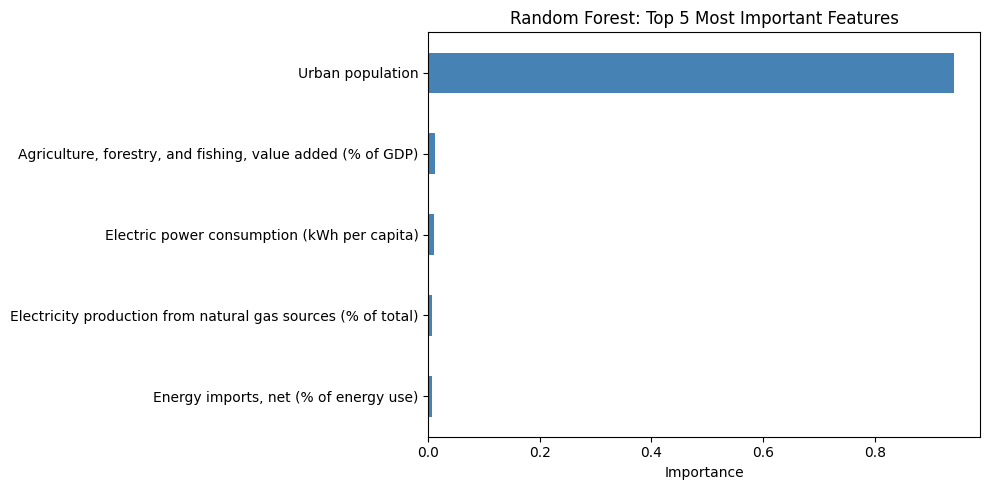

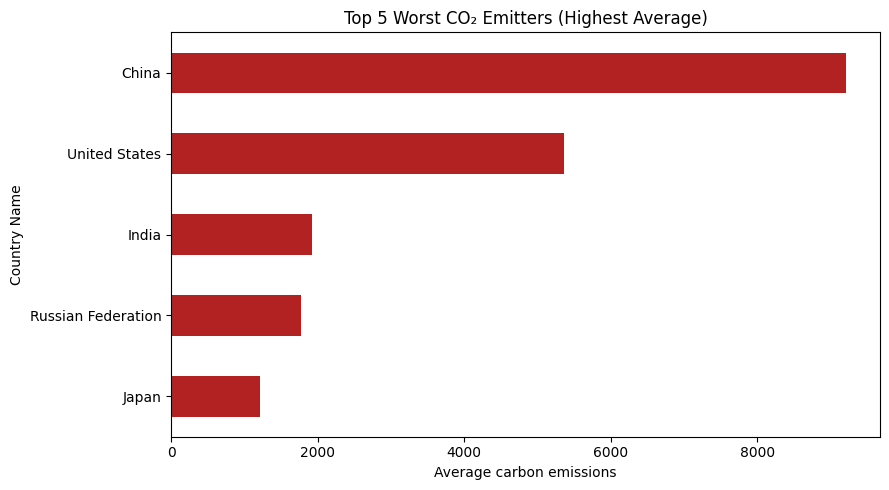

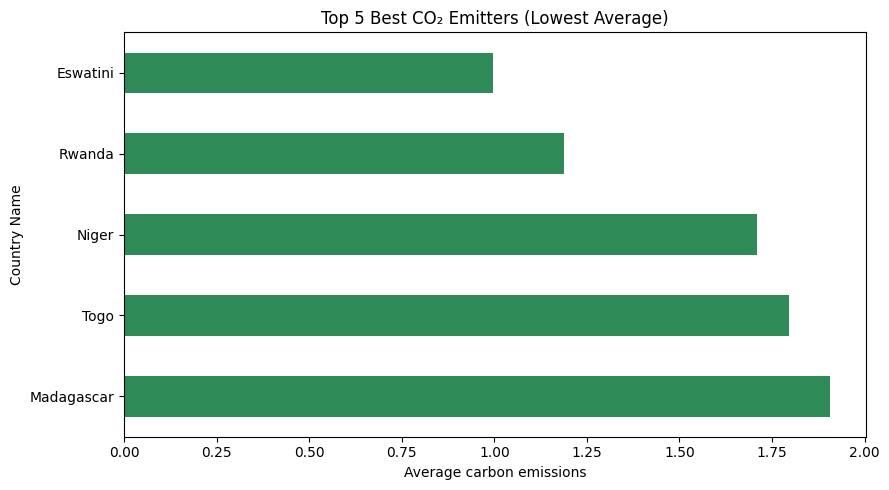

In [11]:
# Plots

imp = (
    pd.Series(best_rf.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)
top5 = imp.head(5)

plt.figure(figsize=(10, 5))
top5[::-1].plot(kind='barh', color='steelblue')
plt.title('Random Forest: Top 5 Most Important Features')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

df = pd.read_csv('pre_split.csv')

country_avg = (
    df.groupby('Country Name')['carbon_emissions']
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

worst5 = country_avg.head(5)

plt.figure(figsize=(9, 5))
worst5[::-1].plot(kind='barh', color='firebrick')
plt.title('Top 5 Worst CO₂ Emitters (Highest Average)')
plt.xlabel('Average carbon emissions')
plt.tight_layout()
plt.show()

best5 = country_avg.tail(5).sort_values()

plt.figure(figsize=(9, 5))
best5[::-1].plot(kind='barh', color='seagreen')
plt.title('Top 5 Best CO₂ Emitters (Lowest Average)')
plt.xlabel('Average carbon emissions')
plt.tight_layout()
plt.show()